#  Data Profiler: Data Preprocessing and Feature Engineering

## IMPORT LIBRARIES

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import requests

## LOAD DATASET

In [15]:
df_csv = pd.read_csv("customer_churn_records.csv")
print('load csv file successfully!')
df_csv.head(1)

load csv file successfully!


,Customer_ID,Name,Age,Gender,City,Income,Tenure_Months,Total_Purchases,Avg_Order_Value,Last_Purchase_Days_Ago,Payment_Method,Is_Active,Complaints,Discount_Used,Churn
0,1,Vikram,NaN,Male,NaN,NaN,2,95,2753,63,NaN,0,1,NaN,1


In [17]:
# Convert CSV to JSON 
df_csv.to_json("customer_churn_records.json", orient="records", indent=4)
df_json = pd.read_json("customer_churn_records.json")
df_json.head(1)

,Customer_ID,Name,Age,Gender,City,Income,Tenure_Months,Total_Purchases,Avg_Order_Value,Last_Purchase_Days_Ago,Payment_Method,Is_Active,Complaints,Discount_Used,Churn
0,1,Vikram,NaN,Male,None,NaN,2,95,2753,63,None,0,1,NaN,1


In [21]:
# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

df = pd.read_csv('customer_churn.csv')

df.to_sql('customer_churn', conn, index=False, if_exists='replace')

print("CSV Successfully Loaded into SQLite!")

df_sql = pd.read_sql_query("""
    SELECT 
        Gender,
        AVG(Income) AS AvgIncome,
        AVG(Tenure_Months) AS AvgTenure,
        SUM(Total_Purchases) AS TotalPurchases,
        SUM(CASE WHEN Churn = 1 THEN 1 ELSE 0 END) AS TotalChurn
    FROM customer_churn
    GROUP BY Gender
    ORDER BY AvgIncome DESC
""", conn)

print("\n SQL Query Result:")
print(df_sql)

print(f"\nShape: {df_sql.shape}")

conn.close()

CSV Successfully Loaded into SQLite!

 SQL Query Result:
   Gender     AvgIncome  AvgTenure  TotalPurchases  TotalChurn
0    None  71587.250000  20.800000           118.0           4
1  Female  63304.043478  34.255319          2320.0          40
2    Male  59081.361702  27.804348          2015.0          39

Shape: (3, 5)


In [23]:
#  Define endpoint
url = "https://jsonplaceholder.typicode.com/users"

# Call API
response = requests.get(url, timeout=10)
response.raise_for_status()
data = response.json()

#  Convert JSON → DataFrame
users_df = pd.json_normalize(data)

#  Display
print(" Users Data Fetched Successfully!")
print("Shape:", users_df.shape)
print("\nFirst 5 Rows:\n", users_df.head(1))

 Users Data Fetched Successfully!
Shape: (10, 15)

First 5 Rows:
    id           name username              email                  phone  \
0   1  Leanne Graham     Bret  Sincere@april.biz  1-770-736-8031 x56442   

         website address.street address.suite address.city address.zipcode  \
0  hildegard.org    Kulas Light      Apt. 556  Gwenborough      92998-3874   

  address.geo.lat address.geo.lng     company.name  \
0        -37.3159         81.1496  Romaguera-Crona   

                      company.catchPhrase                   company.bs  
0  Multi-layered client-server neural-net  harness real-time e-markets  


## Data Cleaning

In [67]:
df_csv = pd.read_csv("customer_churn_records.csv")
df.head(1)
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             100 non-null    int64  
 1   Name                    100 non-null    object 
 2   Age                     94 non-null     float64
 3   Gender                  95 non-null     object 
 4   City                    95 non-null     object 
 5   Income                  97 non-null     float64
 6   Tenure_Months           98 non-null     float64
 7   Total_Purchases         98 non-null     float64
 8   Avg_Order_Value         97 non-null     float64
 9   Last_Purchase_Days_Ago  95 non-null     float64
 10  Payment_Method          94 non-null     object 
 11  Is_Active               100 non-null    int64  
 12  Complaints              100 non-null    int64  
 13  Discount_Used           97 non-null     float64
 14  Churn                   100 non-null    int

Customer_ID               0
Name                      0
Age                       6
Gender                    5
City                      5
Income                    3
Tenure_Months             2
Total_Purchases           2
Avg_Order_Value           3
Last_Purchase_Days_Ago    5
Payment_Method            6
Is_Active                 0
Complaints                0
Discount_Used             3
Churn                     0
dtype: int64

In [98]:
num_cols = ["Age", "Income", "Discount_Used","Tenure_Months","Total_Purchases","Avg_Order_Value","Last_Purchase_Days_Ago"]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [100]:
cat_cols = ["City", "Payment_Method","Gender"]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
df.isnull().sum()

Customer_ID               0
Name                      0
Age                       0
Gender                    0
City                      0
Income                    0
Tenure_Months             0
Total_Purchases           0
Avg_Order_Value           0
Last_Purchase_Days_Ago    0
Payment_Method            0
Is_Active                 0
Complaints                0
Discount_Used             0
Churn                     0
dtype: int64

In [102]:
df.duplicated().sum()

0

In [104]:
df.dtypes

Customer_ID                 int64
Name                       object
Age                       float64
Gender                     object
City                       object
Income                    float64
Tenure_Months             float64
Total_Purchases           float64
Avg_Order_Value           float64
Last_Purchase_Days_Ago    float64
Payment_Method             object
Is_Active                   int64
Complaints                  int64
Discount_Used             float64
Churn                       int64
dtype: object

## Exploratory Data Analysis (EDA)

In [108]:
df = pd.read_csv("customer_churn_records.csv")

### Univariate Analysis 

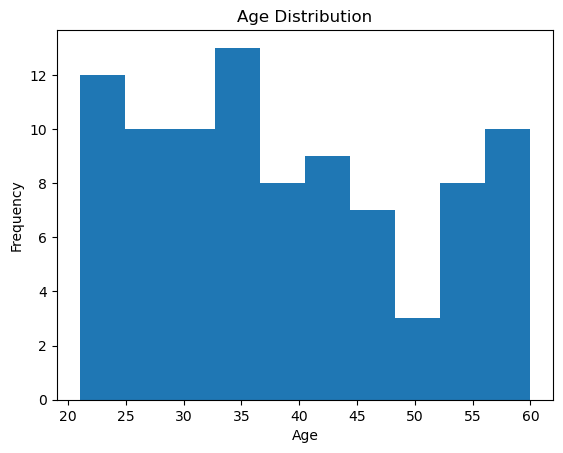

In [110]:
plt.figure()
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

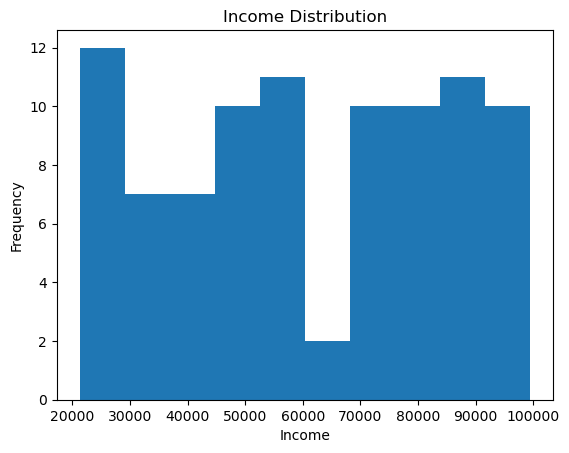

In [112]:
plt.figure()
plt.hist(df["Income"], bins=10)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

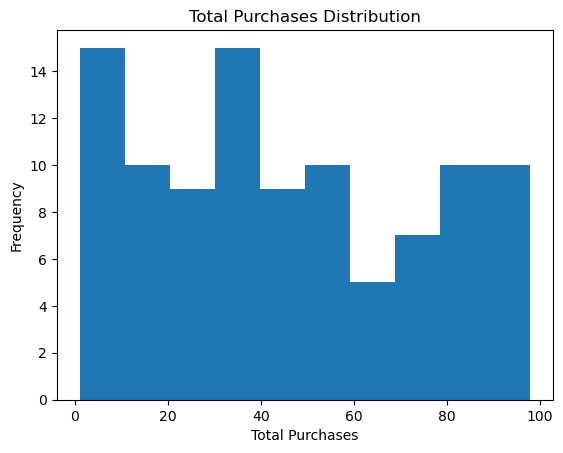

In [114]:
plt.figure()
plt.hist(df["Total_Purchases"], bins=10)
plt.title("Total Purchases Distribution")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")
plt.show()

### Bivariate Analysis 

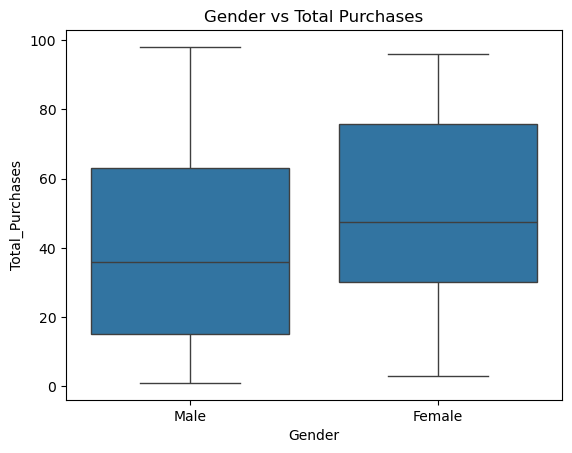

In [116]:
plt.figure()
sns.boxplot(x="Gender", y="Total_Purchases", data=df)
plt.title("Gender vs Total Purchases")
plt.show()

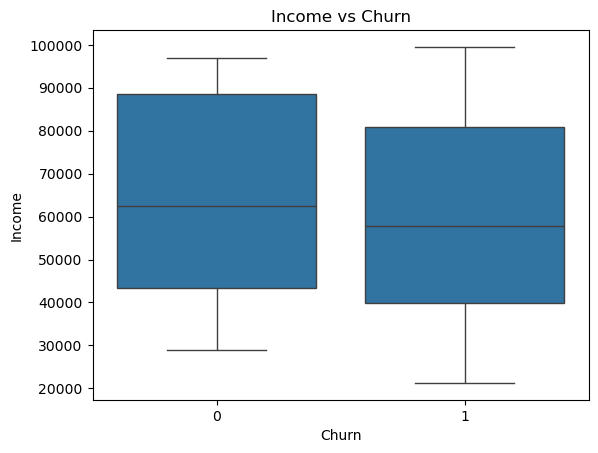

In [118]:
plt.figure()
sns.boxplot(x="Churn", y="Income", data=df)
plt.title("Income vs Churn")
plt.show()

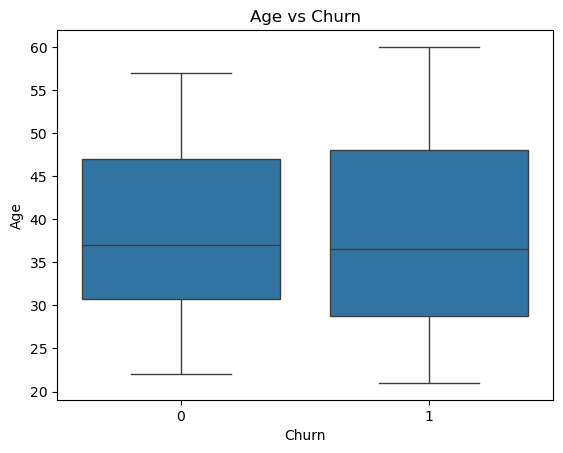

In [120]:
plt.figure()
sns.boxplot(x="Churn", y="Age", data=df)
plt.title("Age vs Churn")
plt.show()

### Multivariate Analysis

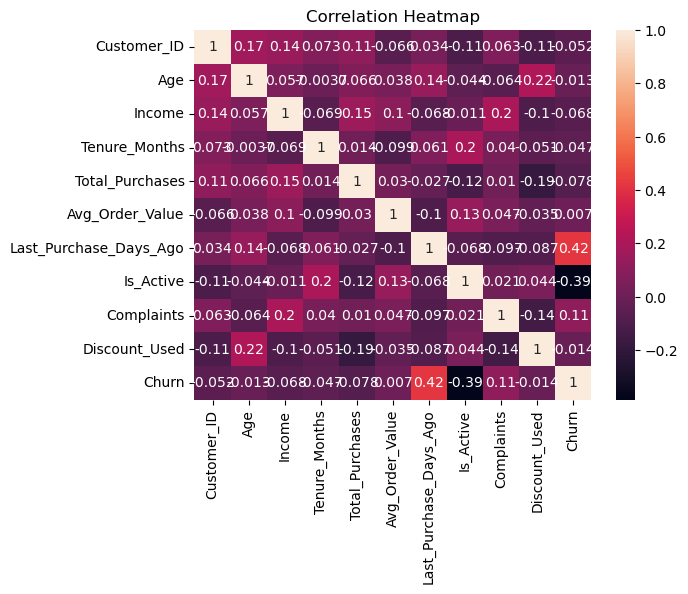

In [122]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

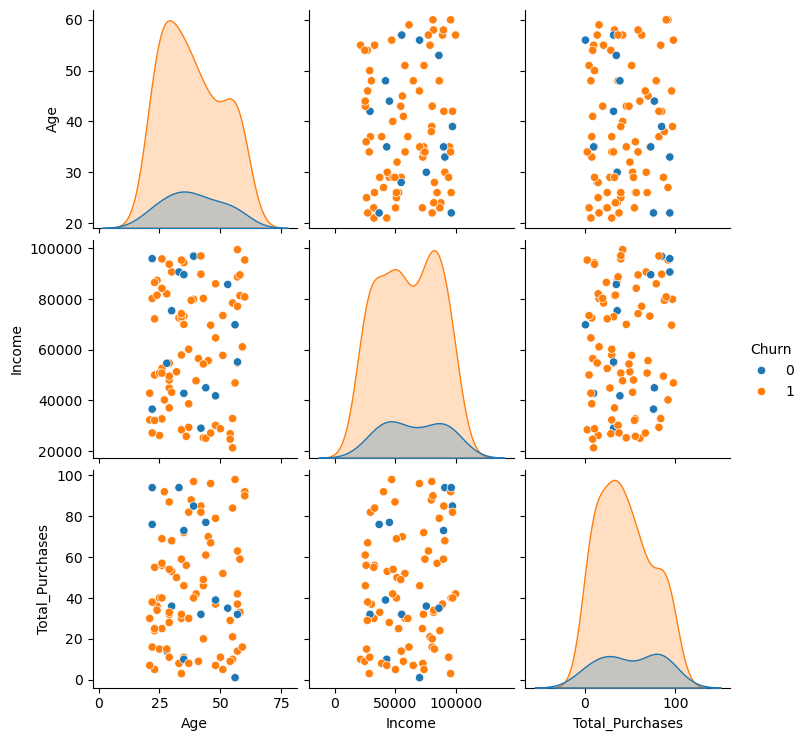

In [124]:
sns.pairplot(df[["Age","Income","Total_Purchases","Churn"]], hue="Churn")
plt.show()

## Data Profiling

In [3]:
from ydata_profiling import ProfileReport
import pandas as pd

df = pd.read_csv("customer_churn_records.csv")

profile = ProfileReport(df, explorative=True)

profile.to_file("Customer_Churn_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 156.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]